### **추가분석 5: 따릉이 대체효과의 자치구 단위 검증 + Pearson 검정**

#### 자치구별 PM 견인/사고 변수와 따릉이 전년동월 증가폭 사이의 상관계수를 계산하고, Pearson 상관계수 검정으로 p-value를 확인합니다.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

def find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'data' / 'data-preprocessing').exists() and (base / 'data' / 'original-datasets').exists():
            return base

        nested = base / 'seoul-pm-safety-analysis'
        if (nested / 'data' / 'data-preprocessing').exists() and (nested / 'data' / 'original-datasets').exists():
            return nested

    raise FileNotFoundError('GitHub 저장소 루트(seoul-pm-safety-analysis)를 찾을 수 없습니다.')


PROJECT_ROOT = find_project_root()
DATA_PREP_ROOT = PROJECT_ROOT / 'data' / 'data-preprocessing'
ORIGINAL_DATA_ROOT = PROJECT_ROOT / 'data' / 'original-datasets'
print('PROJECT_ROOT:', PROJECT_ROOT)


In [6]:
pm_month = pd.read_csv(DATA_PREP_ROOT / '서울시 PM 교통사고 현황' / '서울시_자치구별_월별_PM교통사고.csv', encoding='utf-8')
tow = pd.read_csv(DATA_PREP_ROOT / '서울시 전동킥보드 견인 현황' / '서울특별시_전동킥보드_견인_현황_202107~202512.csv', encoding='utf-8')
bike = pd.read_csv(DATA_PREP_ROOT / '서울시 따릉이 월별 이용정보 통합' / '따릉이_월별_이용정보_통합.csv', encoding='utf-8')

pm_month['연월_dt'] = pd.to_datetime(pm_month['연월'] + '-01')
tow['신고월_dt'] = pd.to_datetime(tow['신고월'] + '-01')
bike['연월_dt'] = pd.to_datetime(bike['연월'] + '-01')

bike_m = bike.groupby(['자치구', '연월_dt'], as_index=False)['이용건수'].sum().sort_values(['자치구', '연월_dt'])
bike_m['전년동월_이용건수'] = bike_m.groupby('자치구')['이용건수'].shift(12)
bike_m['전년동월증감'] = bike_m['이용건수'] - bike_m['전년동월_이용건수']
bike_m['전년동월증감률(%)'] = bike_m['전년동월증감'] / bike_m['전년동월_이용건수'] * 100

pm_m = pm_month.groupby(['자치구', '연월_dt'], as_index=False)['PM_사고건수'].sum()
tow_m = tow.groupby(['구정보', '신고월_dt']).size().rename('견인건수').reset_index().rename(columns={'구정보': '자치구', '신고월_dt': '연월_dt'})
panel = bike_m.merge(pm_m, on=['자치구', '연월_dt'], how='left').merge(tow_m, on=['자치구', '연월_dt'], how='left')
valid_districts = set(pm_month['자치구'].dropna().unique())
panel = panel[panel['자치구'].isin(valid_districts)]
panel[['PM_사고건수', '견인건수']] = panel[['PM_사고건수', '견인건수']].fillna(0)

post = panel[(panel['연월_dt'] >= '2021-07-01') & (panel['연월_dt'] <= '2024-12-01')]
district = post.groupby('자치구').agg(
    규제후_PM사고건수=('PM_사고건수', 'sum'),
    규제후_견인건수=('견인건수', 'sum'),
    규제후_따릉이이용건수=('이용건수', 'sum'),
    규제후_월평균_따릉이YoY증감=('전년동월증감', 'mean'),
    규제후_월평균_따릉이YoY증감률=('전년동월증감률(%)', 'mean'),
).reset_index()

before = panel[(panel['연월_dt'] >= '2020-07-01') & (panel['연월_dt'] <= '2021-06-01')]
after = panel[(panel['연월_dt'] >= '2021-08-01') & (panel['연월_dt'] <= '2022-07-01')]
b = before.groupby('자치구').agg(직전12개월_월평균_PM사고=('PM_사고건수', 'mean'), 직전12개월_월평균_따릉이YoY증감=('전년동월증감', 'mean'))
a = after.groupby('자치구').agg(직후12개월_월평균_PM사고=('PM_사고건수', 'mean'), 직후12개월_월평균_따릉이YoY증감=('전년동월증감', 'mean'))
district = district.merge(b, on='자치구', how='left').merge(a, on='자치구', how='left')
district['PM사고_직후변화'] = district['직후12개월_월평균_PM사고'] - district['직전12개월_월평균_PM사고']
district['따릉이YoY증감_직후변화'] = district['직후12개월_월평균_따릉이YoY증감'] - district['직전12개월_월평균_따릉이YoY증감']
display(district.sort_values('규제후_견인건수', ascending=False).head(10))


,자치구,규제후_PM사고건수,규제후_견인건수,규제후_따릉이이용건수,규제후_월평균_따릉이YoY증감,규제후_월평균_따릉이YoY증감률,직전12개월_월평균_PM사고,직전12개월_월평균_따릉이YoY증감,직후12개월_월평균_PM사고,직후12개월_월평균_따릉이YoY증감,PM사고_직후변화,따릉이YoY증감_직후변화
0,강남구,409.0,24686.0,4479767,14877.487805,21.434842,11.333333,-946.500000,7.272727,22631.181818,-4.060606,23577.681818
17,송파구,251.0,18778.0,12999461,46433.560976,28.828512,5.416667,21978.416667,5.000000,106771.000000,-0.416667,84792.583333
12,마포구,101.0,18579.0,7304764,12668.536585,12.282686,4.916667,7798.333333,2.363636,37323.454545,-2.553030,29525.121212
15,성동구,58.0,18437.0,5609950,15258.390244,17.982519,2.083333,9885.000000,2.000000,26446.090909,-0.083333,16561.090909
19,영등포구,82.0,15862.0,12072429,42249.024390,23.053044,2.000000,28995.916667,2.181818,70261.090909,0.181818,41265.174242
14,서초구,117.0,15428.0,4387244,7545.243902,11.527528,3.833333,6151.000000,2.727273,15502.272727,-1.106061,9351.272727
11,동작구,74.0,11332.0,2935627,3620.658537,10.310137,1.250000,10172.166667,1.909091,10479.000000,0.659091,306.833333
4,관악구,78.0,11263.0,3645695,869.292683,5.211176,3.416667,14899.250000,1.818182,18742.909091,-1.598485,3843.659091
10,동대문구,77.0,10876.0,5055096,11446.975610,16.114514,2.166667,20778.416667,2.090909,29883.363636,-0.075758,9104.946970
20,용산구,25.0,10720.0,2969782,6045.024390,14.748760,0.666667,12501.333333,0.454545,16314.363636,-0.212121,3813.030303


In [7]:
pairs = [
    ('규제후 견인건수 vs 규제후 월평균 따릉이 YoY 증감', '규제후_견인건수', '규제후_월평균_따릉이YoY증감'),
    ('규제후 PM 사고건수 vs 규제후 월평균 따릉이 YoY 증감', '규제후_PM사고건수', '규제후_월평균_따릉이YoY증감'),
    ('PM 사고 직후 변화 vs 따릉이 YoY 직후 변화', 'PM사고_직후변화', '따릉이YoY증감_직후변화'),
]

rows = []
for label, xcol, ycol in pairs:
    s = district[[xcol, ycol]].replace([np.inf, -np.inf], np.nan).dropna()
    r, p_value = stats.pearsonr(s[xcol], s[ycol])
    rows.append({
        '관계': label,
        '상관계수(r)': r,
        'p-value': p_value,
        '표본수(n)': len(s),
        '유의여부(p<0.05)': '유의' if p_value < 0.05 else '유의하지 않음'
    })

corr_result = pd.DataFrame(rows)
display(corr_result)


,관계,상관계수(r),p-value,표본수(n),유의여부(p<0.05)
0,규제후 견인건수 vs 규제후 월평균 따릉이 YoY 증감,0.221951,0.286282,25,유의하지 않음
1,규제후 PM 사고건수 vs 규제후 월평균 따릉이 YoY 증감,0.264620,0.201146,25,유의하지 않음
2,PM 사고 직후 변화 vs 따릉이 YoY 직후 변화,-0.199070,0.340091,25,유의하지 않음


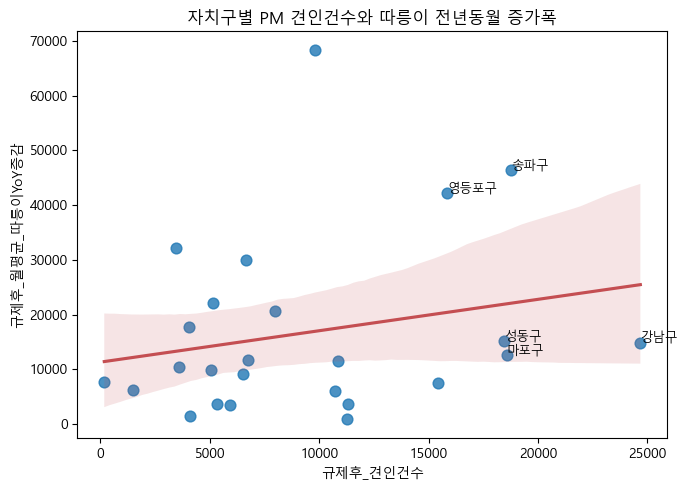

In [8]:
plt.figure(figsize=(7, 5))
sns.regplot(data=district, x='규제후_견인건수', y='규제후_월평균_따릉이YoY증감', scatter_kws={'s': 60}, line_kws={'color': '#c44e52'})
for _, r in district.nlargest(5, '규제후_견인건수').iterrows():
    plt.text(r['규제후_견인건수'], r['규제후_월평균_따릉이YoY증감'], r['자치구'], fontsize=9)
plt.title('자치구별 PM 견인건수와 따릉이 전년동월 증가폭')
plt.tight_layout()
plt.show()


#### Pearson 검정 결과 요약

| 관계 | 상관계수(r) | p-value | 표본수(n) | 유의여부(p<0.05) |
| --- | --- | --- | --- | --- |
| 규제후 견인건수 vs 규제후 월평균 따릉이 YoY 증감 | 0.2220 | 0.2863 | 25 | 유의하지 않음 |
| 규제후 PM 사고건수 vs 규제후 월평균 따릉이 YoY 증감 | 0.2646 | 0.2011 | 25 | 유의하지 않음 |
| PM 사고 직후 변화 vs 따릉이 YoY 직후 변화 | -0.1991 | 0.3401 | 25 | 유의하지 않음 |

- p-value가 0.05 이상이면, 자치구별 PM 견인/사고 지표와 따릉이 증가폭 사이의 선형 상관관계가 통계적으로 유의하다고 보기 어렵습니다.
- 특히 표본수가 25개 자치구로 제한되므로, 유의성이 확보되지 않을 경우 `대체 효과가 없다`고 단정하기보다는 `현재 자치구 단위 자료만으로는 대체 효과를 확인하기 어렵다`고 표현하는 것이 안전합니다.